<a href="https://colab.research.google.com/github/KonstantinPhD/Student/blob/master/mnist/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Пример из лекции № 12 (MNIST)

In [1]:
#%pip install tensorflow keras
#%pip install keras

1. Подключим необходимые библиотеки

In [2]:
from __future__ import print_function   
import numpy as np
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.utils import to_categorical
import pandas as pd;
import matplotlib.pyplot as plt;

2. Зададим параметры, необходимые для обучения сети. 
>Напомню, что  такое пакет (англ. batch). Возможны два подхода к реализации алгоритма обучения сети, например, используя метод градиентного спуска: стохастический и пакетный. 



>>> Стохастический градиентный спуск (англ. stochastic gradient descent) —
реализация, в которой на каждой итерации алгоритма из обучающей выборки каким-то (случайным) образом выбирается только один объект;


>>> Пакетный (батч) (англ. batch gradient descent) — реализация градиентного спуска, когда на каждой итерации обучающая выборка просматривается целиком, и только после этого изменяются веса модели.



In [3]:
batch_size = 128; #размер партии данных, которая поступает на обучение, т.е.
#обучать сеть будем партиями, битчами
nr_classes = 10; # Количество классов
nr_iterations = 20; #Количество эпох (количество итераций)

In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data() #Загрузка датасета

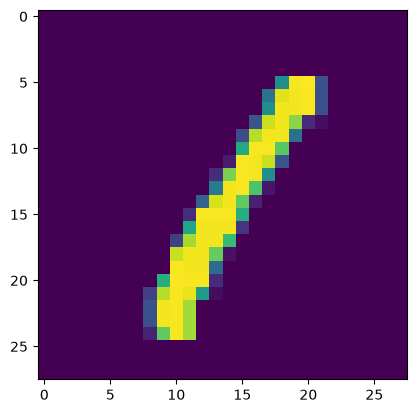

In [5]:
plt.imshow(X_train[3])# Постмотрим на картинку

In [6]:
print("Правильный ответ ",y_train[3])# Посмотрим на ответы в датасете

Правильный ответ  1


In [7]:
#  картинку вытягиваем в столбец
#  Информация о взаимном расположении теряется (не совсем)

X_train = X_train.reshape(60000, 784); # 60000 - это количество картинок, 784 - размер 1-й картинки (28х28=784)
X_test = X_test.reshape(10000, 784);

In [8]:
#  Уточняем тип данных

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

#  Нормируем входные значения, что бы получить числа от 0 до 1!!!
X_train /= 255
X_test /= 255

In [9]:
#  Делаем 10 бинарных столбцов (так как 10 цифр), формируем зависимые переменные, ответы.

Y_train = to_categorical(y_train, nr_classes)
Y_test = to_categorical(y_test, nr_classes)

In [10]:
a=pd.DataFrame(Y_train)# Это не обязательный параметр.

In [11]:
a.head() # Посмотрим, что содержится в данных Y_train

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [12]:
#  Описываем сеть. Входной слой, один внутренний слой, выходной слой. Всего три слоя!!! 

model = Sequential()# Начало создания сети.
model.add(Dense(196, input_shape=(784,))) # входной (784 = 28х28 нейрона) и второй слой (196 нейронов).
model.add(Activation('relu'));
model.add(Dropout(0.5));
model.add(Dense(10))# количество нейронов в выходном слое;
model.add(Activation('softmax'));

C:\Users\assis\anaconda3\envs\sci_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary() #Не обязательный параметр.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 196)                 │         153,860 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 196)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 196)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,970 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 155,830 (608.71 KB)

 Trainable params: 155,830 (608.71 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Параметры целевой функции потерь.
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(),
              metrics=['accuracy'])

In [15]:
np.random.seed(1337)  # для воспроизводимости сети

# Обучаем сеть.
net_res_1 = model.fit(X_train, Y_train,epochs=nr_iterations,
                    batch_size = batch_size,
                    verbose = 1, validation_data = (X_test, Y_test));

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8713 - loss: 0.4403 - val_accuracy: 0.9454 - val_loss: 0.1918
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9352 - loss: 0.2242 - val_accuracy: 0.9601 - val_loss: 0.1383
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9487 - loss: 0.1761 - val_accuracy: 0.9654 - val_loss: 0.1132
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9560 - loss: 0.1507 - val_accuracy: 0.9704 - val_loss: 0.0977
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9604 - loss: 0.1343 - val_accuracy: 0.9736 - val_loss: 0.0877
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9638 - loss: 0.1191 - val_accuracy: 0.9744 - val_loss: 0.0826
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9664 - loss: 0.1108 - val_accuracy: 0.9756 - val_loss: 0.0796
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9689 - loss: 0.1018 - val_accuracy: 0.

In [16]:
score = model.evaluate(X_test, Y_test, verbose = 0)# Вычислим ошибки обучения.
print(score) 

[0.06652066111564636, 0.9815999865531921]


**Проверим работу модели, визуально**

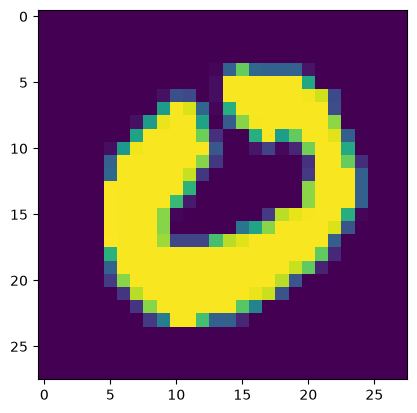

In [17]:
plt.imshow(X_test[25].reshape(28,28))# Посмотрим на картинку №28.

In [18]:
df=X_test[25].reshape(1,784); #Растянем картинку в вектор.

ans=model.predict(df);# Воспользуемся моделью для решения задачи классификации.

ans=pd.DataFrame(ans);# Представим ответ в формате DataFrame для удобства просмотра

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [19]:
round(ans,2)# Посмотрим на результат.

,0,1,2,3,4,5,6,7,8,9
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Спасибо за внимание!!!